In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
import nltk
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import DataLoader, TensorDataset
import nbformat

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
code_sections_extracts_df = pd.read_csv('/content/drive/MyDrive/thesis/part2 model-creation/2.1 feature cration/code_sections_extracts.csv')

code_sections_extracts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Username                    2000 non-null   object 
 1   Display_Name                2000 non-null   object 
 2   Gender                      2000 non-null   object 
 3   notebook_url                2000 non-null   object 
 4   code_location               2000 non-null   object 
 5   labels                      2000 non-null   object 
 6   top_labels                  2000 non-null   object 
 7   code_sections               2000 non-null   object 
 8   markdown_sections           2000 non-null   object 
 9   all_sections                2000 non-null   object 
 10  only_code_in_code_sections  2000 non-null   object 
 11  parsed_code                 1994 non-null   object 
 12  num_of_sections             2000 non-null   int64  
 13  token_count                 2000 

In [4]:
code_sections_extracts_df.head()

,Username,Display_Name,Gender,notebook_url,code_location,labels,top_labels,code_sections,markdown_sections,all_sections,...,token_count,comment_rows_density,function_density,loop_density,condition_density,comment_tokens_density,variables_count,function_count,loop_count,condition_count
0,tchaye59,Jude TCHAYE,male,https://www.kaggle.com/code/tchaye59/jmarket-k...,/content/drive/MyDrive/thesis/notebooks/male/t...,"['Jane Street Market Prediction', 'Jane Street...",{'Jane Street Market Prediction'},['# This Python 3 environment comes with many ...,['### This notebook is only dedicated to submi...,"[{'cell_type': 'code', 'execution_count': 1, '...",...,144,0.400000,0.000000,0.100000,0.000000,0.524272,31,0,3,0
1,iyara1,Riya,female,https://www.kaggle.com/code/iyara1/deepanalysi...,/content/drive/MyDrive/thesis/notebooks/female...,['House Prices - Advanced Regression Techniques'],{'House Prices - Advanced Regression Techniques'},"[""import numpy as np\nimport pandas as pd\nimp...",['**#Bivariate Analysis******'],[{'metadata': {'_uuid': '8f2839f25d086af736a60...,...,423,0.174528,0.004717,0.033019,0.023585,0.359568,100,1,7,5
2,sanjay7013,Sanjay M,male,https://www.kaggle.com/code/sanjay7013/credit-...,/content/drive/MyDrive/thesis/notebooks/male/s...,['Credit Card Fraud Detection'],{'Credit Card Fraud Detection'},['# This Python 3 environment comes with many ...,"['# Credit Card Fraud Detection', ""### DataSet...","[{'cell_type': 'markdown', 'id': '96d4bfeb', '...",...,209,0.239130,0.000000,0.043478,0.000000,0.383648,53,0,2,0
3,validmodel,Rashmi Margani,female,https://www.kaggle.com/code/validmodel/master-...,/content/drive/MyDrive/thesis/notebooks/female...,['Iris Species'],{'Iris Species'},['# This Python 3 environment comes with many ...,"[""# <h1 style='background:#f0c2c1; border:2; b...","[{'cell_type': 'code', 'source': '# This Pytho...",...,472,0.139241,0.050633,0.025316,0.042194,0.279314,96,12,6,10
4,rajeevnair676,Rajeev Nair,male,https://www.kaggle.com/code/rajeevnair676/nlp-...,/content/drive/MyDrive/thesis/notebooks/male/r...,"['IMDB Dataset of 50K Movie Reviews', 'Tweet S...",{'Natural Language Processing with Disaster Tw...,['#Importing NLTK package\nimport nltk\n\nimpo...,['# <center><b> NLP STARTERS - PART 1 <center/...,"[{'cell_type': 'markdown', 'id': 'bf707f5e', '...",...,260,0.165217,0.043478,0.078261,0.017391,0.193370,70,5,9,2


In [5]:
code_sections_extracts_df['Gender'] = code_sections_extracts_df['Gender'].map({'male': 1, 'female': 0})

In [6]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=0)

y = code_sections_extracts_df.Gender

#BERT- MARKDOWN SECTIONS

In [7]:
for i, (train_index, test_index) in enumerate(sgkf.split(code_sections_extracts_df, y, code_sections_extracts_df.Username)):
  X_train = code_sections_extracts_df.markdown_sections.iloc[train_index]
  y_train = code_sections_extracts_df.Gender.iloc[train_index]
  X_test = code_sections_extracts_df.markdown_sections.iloc[test_index]
  y_test = code_sections_extracts_df.Gender.iloc[test_index]

In [8]:
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [9]:
train_texts = X_train.str.lower().tolist()
test_texts = X_test.str.lower().tolist()

train_encodings = tokenizer(train_texts, truncation=True, padding=True, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True, return_tensors='pt')

In [10]:
train_encodings = {key: value for key, value in train_encodings.items()}
test_encodings = {key: value for key, value in test_encodings.items()}
y_train = torch.tensor(y_train.values)


batch_size = 4
dataset = TensorDataset(train_encodings['input_ids'],train_encodings['attention_mask'], y_train)
dataloader = dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [11]:
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss()

In [12]:
for epoch in range(3):
  for batch in dataloader:
      optimizer.zero_grad()
      input_ids_batch, attention_mask_batch, labels_batch = batch
      input_ids_batch = input_ids_batch.to(device)
      attention_mask_batch = attention_mask_batch.to(device)
      labels_batch = labels_batch.to(device)

      outputs = model(input_ids_batch, attention_mask=attention_mask_batch, labels=labels_batch)
      loss = criterion(outputs.logits, labels_batch)
      loss.backward()
      optimizer.step()

In [13]:
batch_size = 8
test_dataloader = DataLoader(TensorDataset(test_encodings['input_ids'], torch.tensor(y_test.values)), batch_size=batch_size)

model.eval()

predictions = torch.Tensor([]).to(device)

with torch.no_grad():
    for batch in test_dataloader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs, return_dict=False)

        predictions = torch.cat((predictions,torch.argmax(outputs[0], dim=1)))


print(classification_report(y_test, predictions.cpu().data))

We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


              precision    recall  f1-score   support

           0       0.59      0.42      0.49       250
           1       0.54      0.69      0.60       240

    accuracy                           0.56       490
   macro avg       0.56      0.56      0.55       490
weighted avg       0.56      0.56      0.55       490



f1_score :  0.6036363636363637


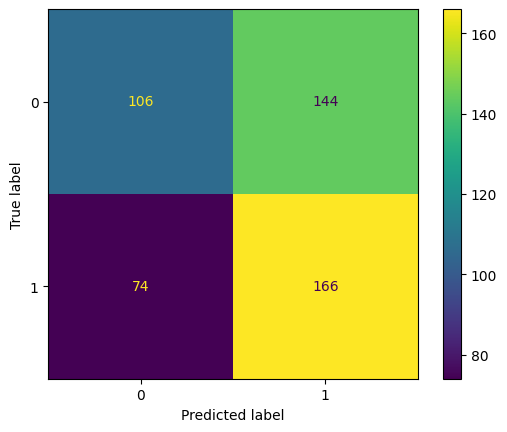

In [14]:
print("f1_score : ",f1_score(y_test, predictions.cpu().data))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predictions.cpu().data))

disp.plot()

plt.show()

In [15]:
del model

#BERT- ALL SECTIONS

In [16]:
X_train = code_sections_extracts_df.all_sections.iloc[train_index]
X_test = code_sections_extracts_df.all_sections.iloc[test_index]

In [17]:
model = BertForSequenceClassification.from_pretrained(model_name)

model.to(device)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:72: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [ ]:
train_texts = X_train.str.lower().tolist()
test_texts = X_test.str.lower().tolist()

train_encodings = tokenizer(train_texts, truncation=True, padding=True, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True, return_tensors='pt')

In [ ]:
train_encodings = {key: value for key, value in train_encodings.items()}
test_encodings = {key: value for key, value in test_encodings.items()}
y_train = torch.tensor(y_train.values)

batch_size = 4
dataset = TensorDataset(train_encodings['input_ids'],train_encodings['attention_mask'], y_train)
dataloader = dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
# Train the BERT model
model.train()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
for epoch in range(3):
  for batch in dataloader:
      optimizer.zero_grad()
      input_ids_batch, attention_mask_batch, labels_batch = batch
      input_ids_batch = input_ids_batch.to(device)
      attention_mask_batch = attention_mask_batch.to(device)
      labels_batch = labels_batch.to(device)

      # Forward pass, backward pass, and optimization go here
      outputs = model(input_ids_batch, attention_mask=attention_mask_batch, labels=labels_batch)
      loss = criterion(outputs.logits, labels_batch)
      loss.backward()
      optimizer.step()

In [ ]:
# Create a DataLoader for validation
batch_size = 8  # Adjust the batch size based on your GPU memory
test_dataloader = DataLoader(TensorDataset(test_encodings['input_ids'], torch.tensor(y_test.values)), batch_size=batch_size)

# Evaluation loop
model.eval()

predictions = torch.Tensor([]).to(device)

with torch.no_grad():  # Avoid computing gradients during validation
    for batch in test_dataloader:
        inputs, targets = batch
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs, return_dict=False)

        predictions = torch.cat((predictions,torch.argmax(outputs[0], dim=1)))


print(classification_report(y_test, predictions.cpu().data))

In [ ]:
print("f1_score : ",f1_score(y_test, predictions.cpu().data))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, predictions.cpu().data))

disp.plot()

plt.show()

In [ ]:
del model